In [20]:
import pandas as pd

df = pd.read_csv('../data/deliveries.csv')

df = df.fillna(0)

In [21]:
df.isnull().sum()

match_id            0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batter              0
bowler              0
non_striker         0
batsman_runs        0
extra_runs          0
total_runs          0
extras_type         0
is_wicket           0
player_dismissed    0
dismissal_kind      0
fielder             0
dtype: int64

In [22]:
df.columns = df.columns.str.strip()

In [23]:
df['wide_runs'] = df.apply(lambda x: x['extra_runs'] if x['extras_type'] == 'wides' else 0, axis=1)
df['noball_runs'] = df.apply(lambda x: x['extra_runs'] if x['extras_type'] == 'noballs' else 0, axis=1)
df['bye_runs'] = df.apply(lambda x: x['extra_runs'] if x['extras_type'] == 'byes' else 0, axis=1)
df['legbye_runs'] = df.apply(lambda x: x['extra_runs'] if x['extras_type'] == 'legbyes' else 0, axis=1)

In [24]:
extras_cols = ['wide_runs', 'noball_runs', 'bye_runs', 'legbye_runs']

In [25]:
grouped = df.groupby(['bowling_team', 'inning'])[extras_cols].sum().reset_index()

In [26]:
grouped['total_extras'] = grouped[extras_cols].sum(axis=1)

In [27]:
melted = grouped.melt(
    id_vars=['bowling_team', 'inning'],
    value_vars=extras_cols,
    var_name='extra_type',
    value_name='runs'
)

In [28]:
df['extras_type'].unique()

array(['legbyes', 0, 'wides', 'byes', 'noballs', 'penalty'], dtype=object)

In [29]:
grouped = df.groupby(['bowling_team', 'inning'])[extras_cols].sum().reset_index()

In [31]:
grouped.head()

,bowling_team,inning,wide_runs,noball_runs,bye_runs,legbye_runs
0,Chennai Super Kings,1,488,39,49,258
1,Chennai Super Kings,2,585,63,59,301
2,Chennai Super Kings,4,0,0,0,0
3,Deccan Chargers,1,140,28,34,92
4,Deccan Chargers,2,188,21,28,123


In [32]:
grouped['total_extras'] = grouped[extras_cols].sum(axis=1)

In [33]:
grouped.sort_values('total_extras', ascending=False).head()

,bowling_team,inning,wide_runs,noball_runs,bye_runs,legbye_runs,total_extras
30,Mumbai Indians,1,742,82,69,350,1243
31,Mumbai Indians,2,587,68,73,313,1041
24,Kolkata Knight Riders,1,569,88,96,286,1039
46,Royal Challengers Bangalore,1,570,70,94,292,1026
39,Rajasthan Royals,1,575,62,103,284,1024


In [34]:
melted = grouped.melt(
    id_vars=['bowling_team', 'inning'],
    value_vars=extras_cols,
    var_name='extra_type',
    value_name='runs'
)

In [35]:
melted.head()

,bowling_team,inning,extra_type,runs
0,Chennai Super Kings,1,wide_runs,488
1,Chennai Super Kings,2,wide_runs,585
2,Chennai Super Kings,4,wide_runs,0
3,Deccan Chargers,1,wide_runs,140
4,Deccan Chargers,2,wide_runs,188


Matplotlib is building the font cache; this may take a moment.


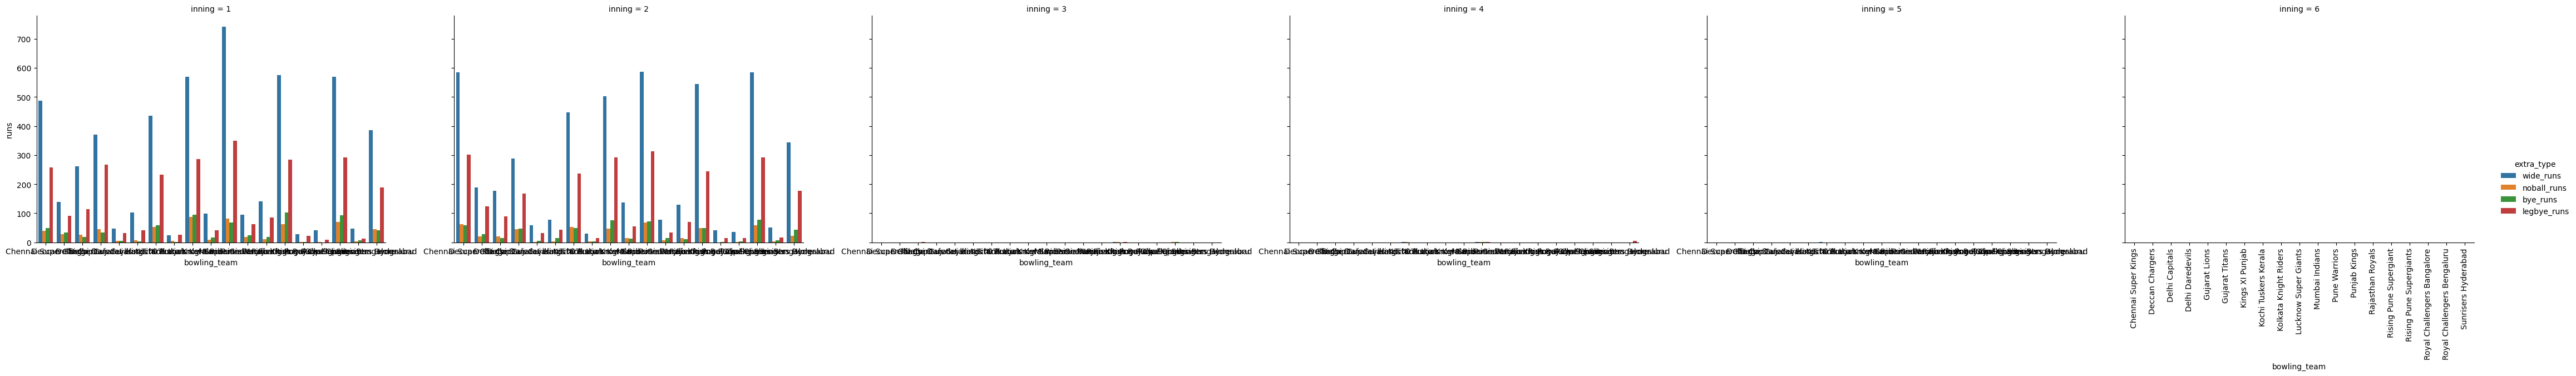

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    data=melted,
    x='bowling_team',
    y='runs',
    hue='extra_type',
    col='inning',
    kind='bar',
    height=5,
    aspect=1.5
)

plt.xticks(rotation=90)
plt.show()

## Insight Summary

- Wide runs are the most common extras across most teams.
- Extras tend to increase in the 2nd innings due to pressure situations.
- Some teams maintain lower extras consistently, indicating better discipline.
- Byes and leg byes are relatively less frequent compared to wides and no-balls.